In [5]:
import torch
import torchvision.transforms as transforms
from torchvision.datasets import EMNIST
torch.manual_seed(162179)

In [6]:
to_tensor = transforms.Compose([
    transforms.Grayscale(num_output_channels=1), transforms.ToTensor()
])
dataset = EMNIST(root="data_emnist", split="letters", train=True, transform=to_tensor)

# Checking distribution of data

In [7]:
df = list(dataset.train_labels)
df = list(map(lambda x: int(x), df))
bar_df = {}
for i in df:
    bar_df[i] = bar_df.get(i, 0) + 1
bar_df

c:\Users\mokrota\Documents\GitHub\Neural-Network-Project\.venv\Lib\site-packages\torchvision\datasets\mnist.py:66: UserWarning: train_labels has been renamed targets
  warnings.warn("train_labels has been renamed targets")


{23: 4800,
 7: 4800,
 16: 4800,
 15: 4800,
 17: 4800,
 13: 4800,
 11: 4800,
 22: 4800,
 24: 4800,
 10: 4800,
 14: 4800,
 18: 4800,
 21: 4800,
 26: 4800,
 19: 4800,
 5: 4800,
 2: 4800,
 25: 4800,
 9: 4800,
 12: 4800,
 1: 4800,
 8: 4800,
 4: 4800,
 3: 4800,
 20: 4800,
 6: 4800}

In [8]:
import matplotlib.pyplot as plt
def distribution_plot(bar_df):
    fig, ax = plt.subplots()
    ax.bar(list(bar_df.keys()), width=1, edgecolor="white", height=list(bar_df.values()))
    plt.show()

c:\Users\mokrota\Documents\GitHub\Neural-Network-Project\.venv\Lib\site-packages\torchvision\datasets\mnist.py:66: UserWarning: train_labels has been renamed targets
  warnings.warn("train_labels has been renamed targets")


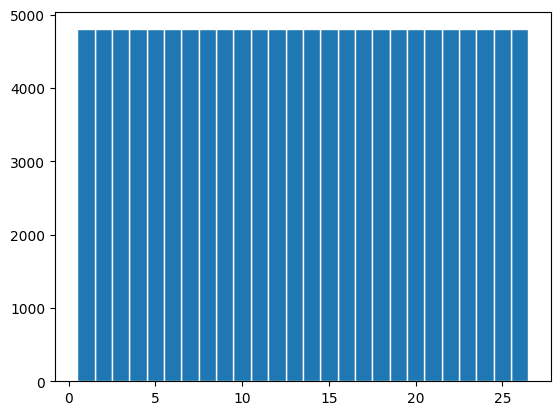

In [9]:
df = list(dataset.train_labels)
df = list(map(lambda x: int(x), df))
bar_df = {}
for i in df:
    bar_df[i] = bar_df.get(i, 0) + 1
distribution_plot(bar_df)

In [10]:
train, validation = torch.utils.data.random_split(dataset, [0.8, 0.2])

In [11]:
train_df = [train.dataset[i][1] for i in train.indices]
train_df = list(map(lambda x: int(x), train_df))
train_bar_df = {}
for i in train_df:
    train_bar_df[i] = train_bar_df.get(i, 0) + 1
print(train_bar_df)

{25: 3779, 4: 3850, 16: 3775, 11: 3808, 26: 3854, 17: 3892, 24: 3857, 9: 3862, 10: 3869, 22: 3911, 15: 3831, 13: 3809, 19: 3825, 2: 3864, 7: 3854, 5: 3882, 3: 3856, 21: 3820, 20: 3804, 23: 3827, 18: 3833, 1: 3840, 8: 3825, 12: 3870, 14: 3844, 6: 3799}


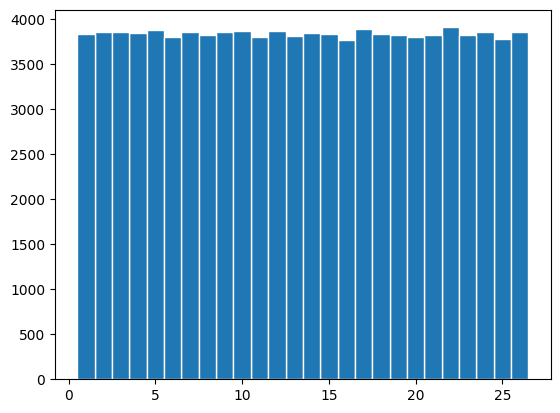

In [12]:
distribution_plot(train_bar_df)

In [13]:
validation_df = [validation.dataset[i][1] for i in validation.indices]
validation_df = list(map(lambda x: int(x), validation_df))
validation_bar_df = {}
for i in validation_df:
    validation_bar_df[i] = validation_bar_df.get(i, 0) + 1
print(validation_bar_df)

{15: 969, 9: 938, 24: 943, 6: 1001, 16: 1025, 5: 918, 3: 944, 11: 992, 4: 950, 10: 931, 13: 991, 21: 980, 20: 996, 8: 975, 25: 1021, 26: 946, 14: 956, 22: 889, 17: 908, 23: 973, 19: 975, 12: 930, 7: 946, 1: 960, 18: 967, 2: 936}


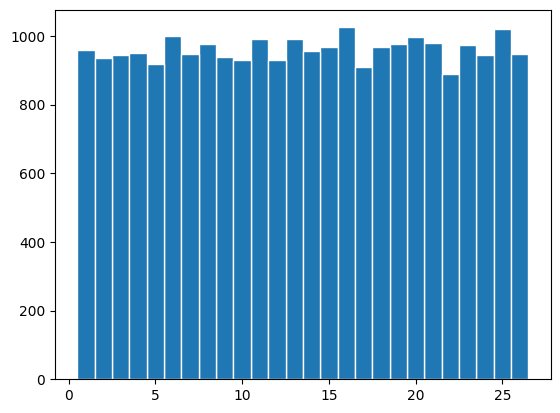

In [14]:
distribution_plot(validation_bar_df)

In [56]:
import json
import os

datas_pyramid = []
counter = 0
filename = "training_pyramid"
wd = os.getcwd()
current_path = os.path.join(wd, 'model', filename + str(counter))
while (os.path.exists(current_path)):
    loss_data_path = os.path.join(current_path, 'loss.json')
    if os.path.exists(loss_data_path):
        with open(loss_data_path, 'r') as file:
            datas_pyramid.append(json.load(file))
    else:
        datas_pyramid.append(None)
    counter += 1
    current_path = os.path.join(wd, 'model', filename + str(counter))


In [50]:
from architecture import ConvNetPooling, nn
import torch
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder, EMNIST
import torchvision.transforms as transforms
import pandas as pd
torch.manual_seed(162179)

def get_unique_folder(path, folder_name):
    counter = 0
    folder_path = os.path.join(path, folder_name + str(counter))
    while os.path.exists(folder_path):
        counter += 1
        folder_path = os.path.join(path, folder_name + str(counter))
    os.mkdir(folder_path)
    return folder_path

descending = True
device = torch.device("cuda")
batch_size = 64
validation_counter = 5
# cur_path = os.path.abspath(__file__)
# save_path = os.path.join(dir_path, 'model')
folder_name = "training"
if descending:
    folder_name += "_pyramid"
else:
    folder_name += "_reverse_pyramid"
# save_path = get_unique_folder(save_path, folder_name)
# loss_path = os.path.join(save_path, "loss.json")

to_tensor = transforms.Compose([
    transforms.Grayscale(num_output_channels=1), transforms.ToTensor()
])
dataset = EMNIST(root="data_emnist", split="letters", train=True, transform=to_tensor)
train_dataset, validation_dataset = torch.utils.data.random_split(dataset, [0.8, 0.2])
trainloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
validationloader = DataLoader(validation_dataset, batch_size=batch_size, shuffle=False)

labels = [label for _, label in dataset]
output_size = len(set(labels))
sample_image, _ = dataset[0]
_, width, height = list(sample_image.shape)

conv_networks_parameters = [torch.randint(3, 20, (2,)).sort(descending=False).values for _ in range(validation_counter)] # increasing pyramid
torch.manual_seed(162179)

def get_unique_folder(path, folder_name):
    counter = 0
    folder_path = os.path.join(path, folder_name + str(counter))
    while os.path.exists(folder_path):
        counter += 1
        folder_path = os.path.join(path, folder_name + str(counter))
    os.mkdir(folder_path)
    return folder_path

descending = True
device = torch.device("cuda")
batch_size = 64
validation_counter = 5
# cur_path = os.path.abspath(__file__)
# save_path = os.path.join(dir_path, 'model')
folder_name = "training"
if descending:
    folder_name += "_pyramid"
else:
    folder_name += "_reverse_pyramid"
# save_path = get_unique_folder(save_path, folder_name)
# loss_path = os.path.join(save_path, "loss.json")

to_tensor = transforms.Compose([
    transforms.Grayscale(num_output_channels=1), transforms.ToTensor()
])
dataset = EMNIST(root="data_emnist", split="letters", train=True, transform=to_tensor)
train_dataset, validation_dataset = torch.utils.data.random_split(dataset, [0.8, 0.2])
trainloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
validationloader = DataLoader(validation_dataset, batch_size=batch_size, shuffle=False)

labels = [label for _, label in dataset]
output_size = len(set(labels))
sample_image, _ = dataset[0]
_, width, height = list(sample_image.shape)

conv_networks_parameters = [torch.randint(16, 64, (2,)).sort(descending=False).values for _ in range(validation_counter)]
exp_powers = torch.randint(-13, -4, (validation_counter,))
alphas = exp_powers.exp2()

In [ ]:
import plotly.graph_objects as go
fig = go.Figure()

for j, loss in enumerate(datas_pyramid[i]):
        x = list(range(len(loss)))
        fig.add_trace(go.Scatter(x=x, y=loss, mode='lines', name=f'Loss: {list(conv_networks_parameters[j])}; Alpha: {alphas[j]:.4f}'))

fig.update_layout(
    title='Cross Entropy Loss Over Batches',
    xaxis_title='Batch',
    yaxis_title='Cross Entropy Loss',
    template='plotly_dark',
    hovermode='x unified'
)

fig.show()
